# Practica 2 - Ejercicio 7: Precio de viviendas en EE.UU.

**Enunciado:** Dataset `USA_Housing.xlsx` con 5000 viviendas. Realizar EDA, construir un
modelo de regresion multiple para predecir el precio de venta, y evaluar el ajuste.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
%matplotlib inline

## PARTE I - Analisis exploratorio

In [2]:
df = pd.read_excel("Datasets/Parte_2/USA_Housing.xlsx")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(f"Columnas: {df.columns.tolist()}")
print(f"Shape: {df.shape}")
print(df.describe())

Columnas: ['avg_area_income', 'avg_area_house_age', 'avg_area_number_of_rooms', 'avg_area_number_of_bedrooms', 'area_population', 'price', 'address']
Shape: (5000, 7)
       avg_area_income  avg_area_house_age  avg_area_number_of_rooms  \
count      5000.000000         5000.000000               5000.000000   
mean      68583.108984            5.977222                  6.987792   
std       10657.991214            0.991456                  1.005833   
min       17796.631190            2.644304                  3.236194   
25%       61480.562388            5.322283                  6.299250   
50%       68804.286404            5.970429                  7.002902   
75%       75783.338666            6.650808                  7.665871   
max      107701.748378            9.519088                 10.759588   

       avg_area_number_of_bedrooms  area_population         price  
count                  5000.000000      5000.000000  5.000000e+03  
mean                      3.981330     36163.516

In [3]:
# Verificar valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
avg_area_income                0
avg_area_house_age             0
avg_area_number_of_rooms       0
avg_area_number_of_bedrooms    0
area_population                0
price                          0
address                        0
dtype: int64


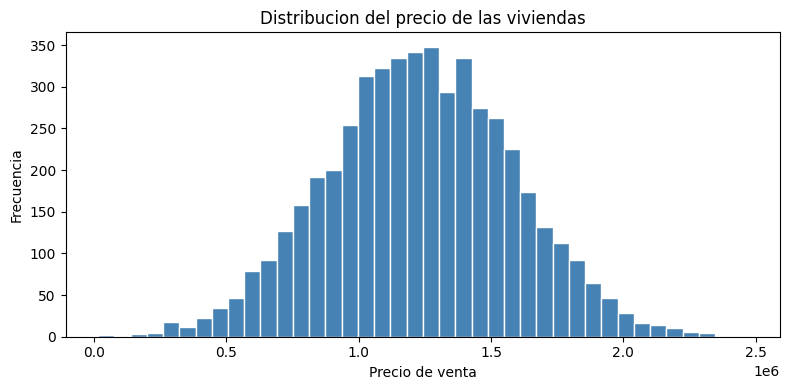

Asimetria (skewness): -0.0027
Distribucion: simetrica


In [4]:
# Distribucion del precio
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["price"], bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("Precio de venta")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribucion del precio de las viviendas")
plt.tight_layout()
plt.show()

skew = df["price"].skew()
print(f"Asimetria (skewness): {skew:.4f}")
print("Distribucion:", "simetrica" if abs(skew) < 0.5 else "asimetrica positiva" if skew > 0 else "asimetrica negativa")

La distribucion del precio es aproximadamente **simetrica** (skewness ≈ 0), lo que es
deseable para el ajuste de modelos de regresion.

Correlaciones con price:
price                          1.000000
avg_area_income                0.639734
avg_area_house_age             0.452543
area_population                0.408556
avg_area_number_of_rooms       0.335664
avg_area_number_of_bedrooms    0.171071
Name: price, dtype: float64


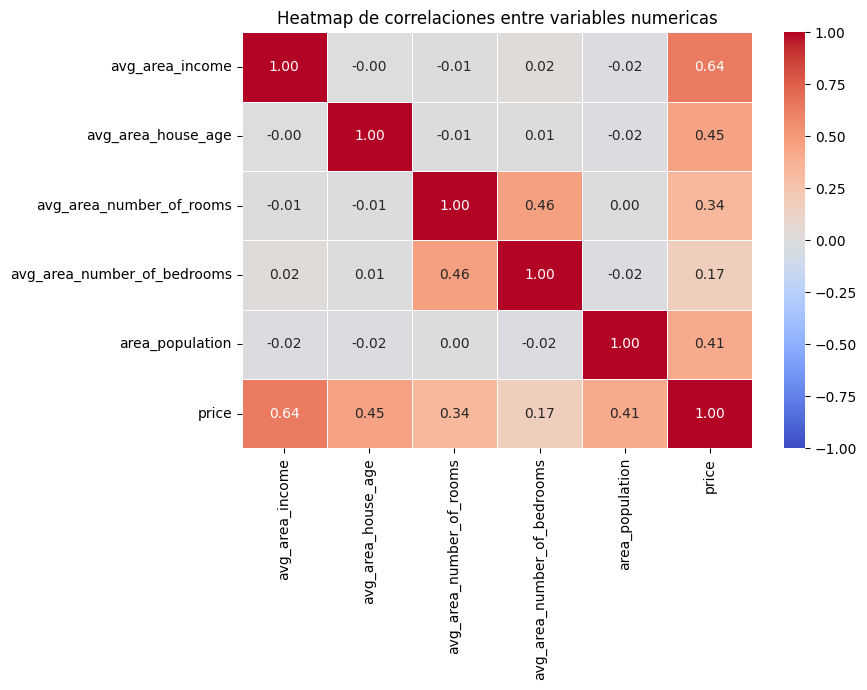

In [5]:
# Heatmap de correlaciones
num_cols = df.select_dtypes(include="number").columns.tolist()
corr = df[num_cols].corr()
print("Correlaciones con price:")
print(corr["price"].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title("Heatmap de correlaciones entre variables numericas")
plt.tight_layout()
plt.show()

Variable mas correlacionada con price: avg_area_income (r=0.6397)


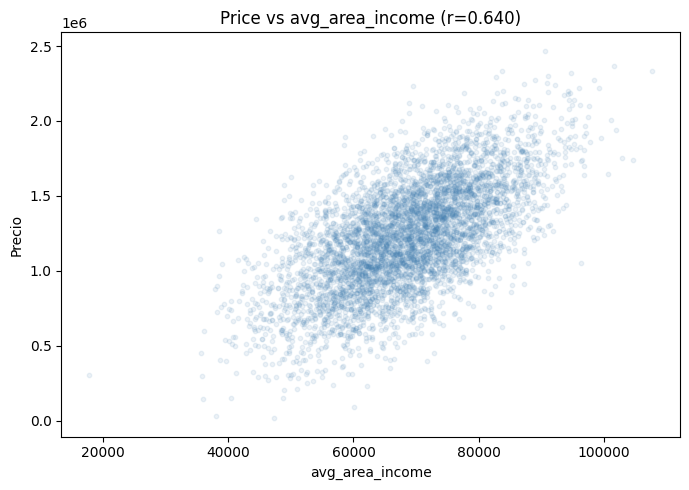

In [6]:
# Par mas correlacionado con price
best_var = corr["price"].drop("price").abs().idxmax()
r_best   = corr["price"][best_var]
print(f"Variable mas correlacionada con price: {best_var} (r={r_best:.4f})")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df[best_var], df["price"], alpha=0.1, s=10, color="steelblue")
ax.set_xlabel(best_var)
ax.set_ylabel("Precio")
ax.set_title(f"Price vs {best_var} (r={r_best:.3f})")
plt.tight_layout()
plt.show()

## PARTE II - Ajuste de modelo

In [7]:
# Modelo completo con todas las variables numericas excepto price
predictores = [c for c in num_cols if c != "price"]
formula_full = "price ~ " + " + ".join(predictores)
print(f"Modelo completo: {formula_full}")

mod_full = smf.ols(formula_full, data=df)
res_full = mod_full.fit()
print(res_full.summary())

Modelo completo: price ~ avg_area_income + avg_area_house_age + avg_area_number_of_rooms + avg_area_number_of_bedrooms + area_population
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 1.119e+04
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:01:45   Log-Likelihood:                -64714.
No. Observations:                5000   AIC:                         1.294e+05
Df Residuals:                    4994   BIC:                         1.295e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|  

In [8]:
print("Significancia de cada variable (alpha=0.05):")
for var, pv in res_full.pvalues.items():
    sig = "SIGNIFICATIVA" if pv < 0.05 else "No significativa"
    print(f"  {var}: p={pv:.4f} -> {sig}")

Significancia de cada variable (alpha=0.05):
  Intercept: p=0.0000 -> SIGNIFICATIVA
  avg_area_income: p=0.0000 -> SIGNIFICATIVA
  avg_area_house_age: p=0.0000 -> SIGNIFICATIVA
  avg_area_number_of_rooms: p=0.0000 -> SIGNIFICATIVA
  avg_area_number_of_bedrooms: p=0.2071 -> No significativa
  area_population: p=0.0000 -> SIGNIFICATIVA


In [9]:
# avg_area_number_of_bedrooms no es significativa -> modelo reducido
formula_red = "price ~ avg_area_income + avg_area_house_age + avg_area_number_of_rooms + area_population"
mod_red = smf.ols(formula_red, data=df)
res_red = mod_red.fit()
print("Modelo reducido:")
print(res_red.summary())

Modelo reducido:
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 1.398e+04
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:01:45   Log-Likelihood:                -64714.
No. Observations:                5000   AIC:                         1.294e+05
Df Residuals:                    4995   BIC:                         1.295e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Interce

In [10]:
print(f"\nComparacion de modelos:")
print(f"  Modelo completo -> R2 ajustado: {res_full.rsquared_adj:.6f}")
print(f"  Modelo reducido -> R2 ajustado: {res_red.rsquared_adj:.6f}")

print("\nCoeficientes del modelo reducido:")
for var, coef in res_red.params.items():
    print(f"  {var}: {coef:,.2f}")


Comparacion de modelos:
  Modelo completo -> R2 ajustado: 0.917942
  Modelo reducido -> R2 ajustado: 0.917932

Coeficientes del modelo reducido:
  Intercept: -2,637,560.67
  avg_area_income: 21.58
  avg_area_house_age: 165,657.87
  avg_area_number_of_rooms: 121,598.16
  area_population: 15.20


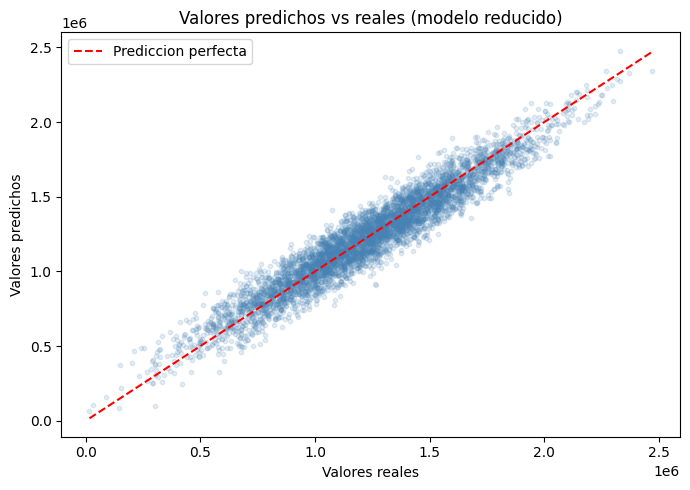

In [11]:
# Grafico valores predichos vs reales
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["price"], res_red.fittedvalues, alpha=0.15, s=10, color="steelblue")
lims = [df["price"].min(), df["price"].max()]
ax.plot(lims, lims, "r--", lw=1.5, label="Prediccion perfecta")
ax.set_xlabel("Valores reales")
ax.set_ylabel("Valores predichos")
ax.set_title("Valores predichos vs reales (modelo reducido)")
ax.legend()
plt.tight_layout()
plt.show()

## Conclusiones

**Modelo final:**

$$\hat{price} = -2{,}637{,}561 + 21.58 \cdot \text{avg\_area\_income} + 165{,}658 \cdot \text{avg\_area\_house\_age} + 121{,}598 \cdot \text{avg\_area\_number\_of\_rooms} + 15.20 \cdot \text{area\_population}$$

**Interpretacion de coeficientes:**
- `avg_area_income` (+21.58): Por cada $ de aumento en el ingreso promedio del area, el precio aumenta $21.58.
- `avg_area_house_age` (+165,658): Por cada ano de antiguedad promedio adicional de las casas del area, el precio sube $165,658.
- `avg_area_number_of_rooms` (+121,598): Por cada ambiente promedio adicional, el precio aumenta $121,598.
- `area_population` (+15.20): Por cada habitante adicional en la ciudad, el precio sube $15.20.

**R² ajustado = 0.918:** El modelo explica el 91.8% de la variabilidad en el precio de venta.

**Variable excluida:** `avg_area_number_of_bedrooms` no fue significativa (p = 0.207).

**Grafico predichos vs reales:** Los puntos se distribuyen cercanos a la diagonal de prediccion
perfecta, confirmando el buen ajuste del modelo.